In [17]:
import pandas as pd
import seaborn as sns
import os
import matplotlib.pyplot as plt 
os.makedirs("figures", exist_ok=True)
titanic = pd.read_csv("../data/titanic_propre.csv")
titanic["survived"] = titanic["survived"].astype(int)
titanic["sexe"] = titanic["sex"].map({"female": "Femmes", "male": "Hommes"})
taxis = sns.load_dataset("taxis")
taxis["pickup"] = pd.to_datetime(taxis["pickup"])
taxis["dropoff"] = pd.to_datetime(taxis["dropoff"])
taxis["duree_min"] = (taxis["dropoff"] - taxis["pickup"]).dt.total_seconds() / 60
taxis = taxis[taxis["duree_min"] > 0]
print(titanic.shape)
print(taxis.shape)
titanic.head()


(889, 10)
(6427, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embark_town,alone,sexe
0,0,3,male,22.0,1,0,7.2500,Southampton,False,Hommes
1,1,1,female,38.0,1,0,71.2833,Cherbourg,False,Femmes
2,1,3,female,26.0,0,0,7.9250,Southampton,True,Femmes
3,1,1,female,35.0,1,0,53.1000,Southampton,False,Femmes
4,0,3,male,35.0,0,0,8.0500,Southampton,True,Hommes


1) age des passagers
histogramme car une seule variable quantitative 

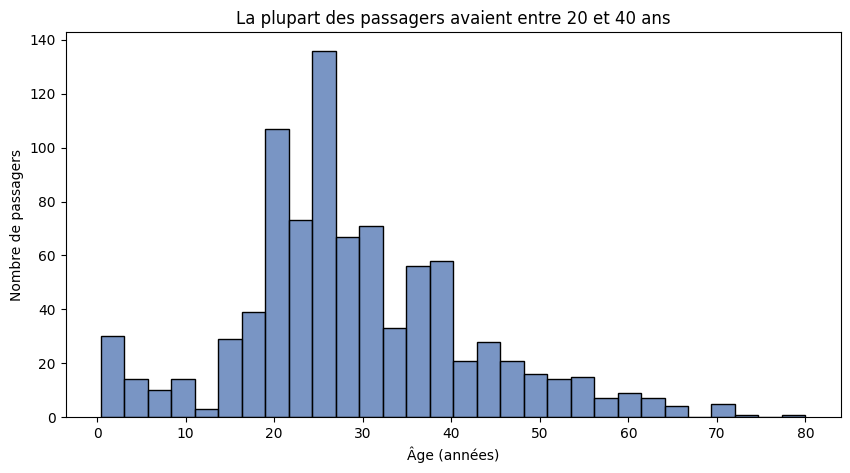

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data=titanic, x="age", bins=30, color="#4C72B0", ax=ax)
ax.set_title("La plupart des passagers avaient entre 20 et 40 ans")
ax.set_xlabel("Âge (années)")
ax.set_ylabel("Nombre de passagers")
fig.savefig("figures/ages.png", dpi=150, bbox_inches="tight")
plt.show()

conclusion = majorité des passagers = jeunes adultes
enfants et seniors (+ de 60) minoritaires

2) survie selon classe et sexe 
barres groupées car compare une mesure entre 2 variables qualitatives et la couleur = le sexe

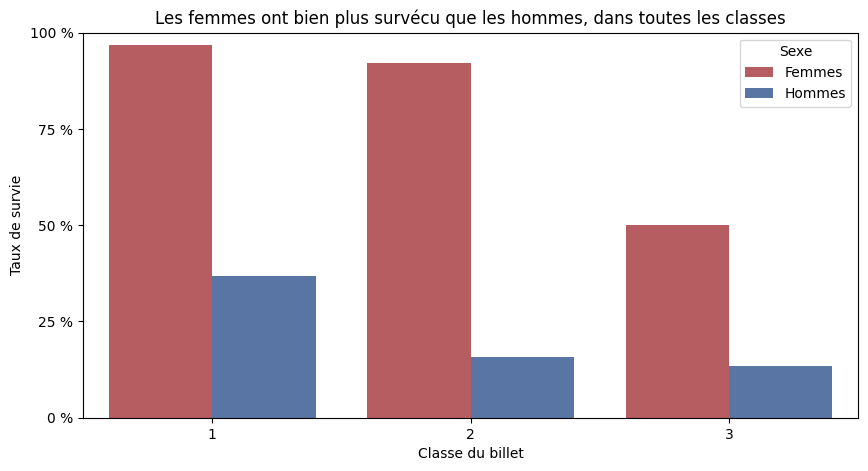

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=titanic, x="pclass", y="survived", hue="sexe",
errorbar=None, palette={"Femmes": "#C44E52", "Hommes": "#4C72B0"}, ax=ax)
ax.set_title("Les femmes ont bien plus survécu que les hommes, dans toutes les classes")
ax.set_xlabel("Classe du billet")
ax.set_ylabel("Taux de survie")
ax.set_ylim(0, 1)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1])
ax.set_yticklabels(["0 %", "25 %", "50 %", "75 %", "100 %"])
ax.legend(title="Sexe")
fig.savefig("figures/survie_classe_sexe.png", dpi=150, bbox_inches="tight")
plt.show()

conclusion = environ 97% des femmes de 1ère classe ont survécu contre environ 35% des hommes et en 3eme classe l'écart reste aussi grand

3) prix du billet selon nla classe
boîte à moustaches, on compare une mesure quantitative entre cat avec les valeurs extremes 

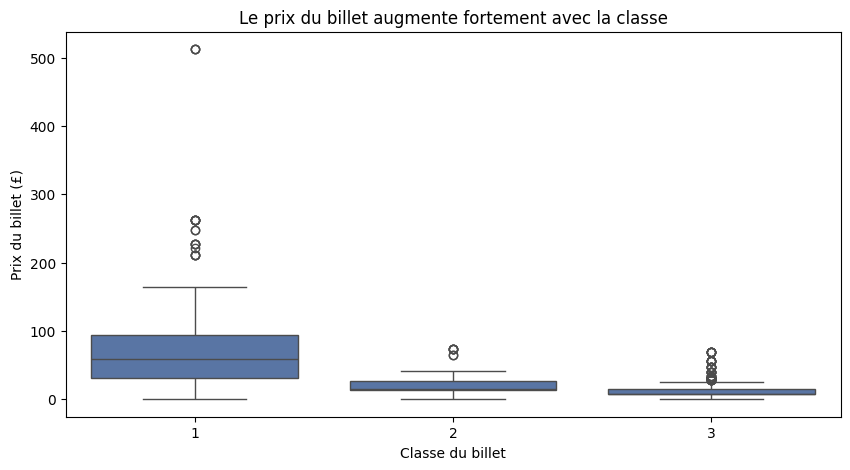

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=titanic, x="pclass", y="fare", color="#4C72B0", ax=ax)
ax.set_title("Le prix du billet augmente fortement avec la classe")
ax.set_xlabel("Classe du billet")
ax.set_ylabel("Prix du billet (£)")
fig.savefig("figures/prix_classe.png", dpi=150, bbox_inches="tight")
plt.show()

4) Taxis le CA jour après jour
courbe car on montre l'évolution d'une mesure dans le temps

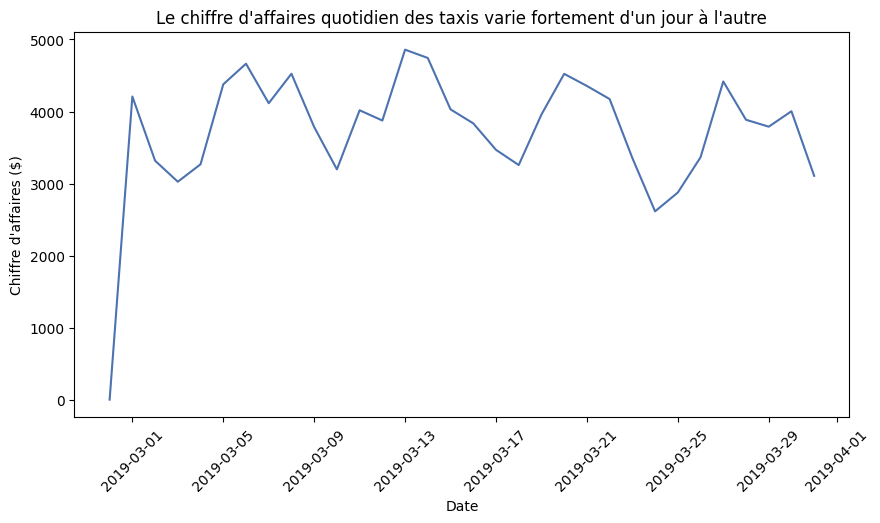

In [21]:
ca_par_jour = taxis.set_index("pickup").resample("D")["total"].sum()
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(x=ca_par_jour.index, y=ca_par_jour.values, color="#4C72B0", ax=ax)
ax.set_title("Le chiffre d'affaires quotidien des taxis varie fortement d'un jour à l'autre")
ax.set_xlabel("Date")
ax.set_ylabel("Chiffre d'affaires ($)")
ax.tick_params(axis="x", rotation=45)
fig.savefig("figures/ca_taxis_jour.png", dpi=150, bbox_inches="tight")
plt.show()

5) Taxis le lien entre distance et prix
nuage de points car on étudie le lien entre deux variables quantitatives

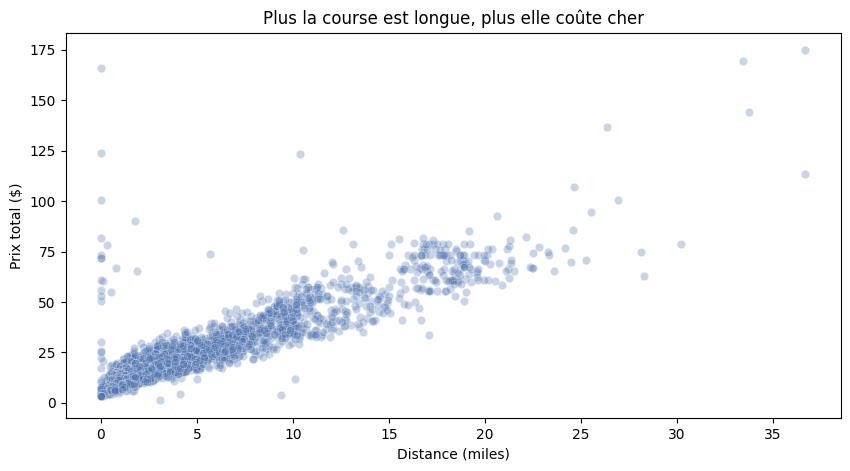

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.scatterplot(data=taxis, x="distance", y="total", alpha=0.3, color="#4C72B0", ax=ax)
ax.set_title("Plus la course est longue, plus elle coûte cher")
ax.set_xlabel("Distance (miles)")
ax.set_ylabel("Prix total ($)")
fig.savefig("figures/distance_prix.png", dpi=150, bbox_inches="tight")
plt.show()

conclusion : le prix augmente quasi linéairement avec la distance 